# Exogenous Transmission Projects, Year by Year (2025-2035)

Diffs `resources/transmission_projects/{new_lines,new_links}.csv` - the raw
project catalog (NEP/TYNDP/manual), pre-clustering - by `build_year`, one
year at a time. Not a solved network: this is purely "what does the project
catalog say comes online in year Y".

In [1]:
import os
os.environ["PROJ_DATA"] = "/home/julian-geis/repos/pypsa-de/.pixi/envs/default/share/proj"

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
import pypsa
import shapely.wkt
import pyproj
pyproj.datadir.set_data_dir("/home/julian-geis/repos/pypsa-de/.pixi/envs/default/share/proj")

REPO = "/home/julian-geis/repos/pypsa-de"
YEARS = range(2025, 2036)

## Config

`SCOPE` controls which projects enter every summary/plot below:

- `"whole_network"` - every new line/link in the catalog, including projects
  with nothing to do with Germany (e.g. TYNDP entries elsewhere in Europe).
- `"de_internal"` - only lines/links with both ends in Germany.
- `"de_and_interconnectors"` **(default)** - DE-internal plus DE-neighbour
  cross-border connections; excludes purely foreign branches.

In [2]:
SCOPE = "de_and_interconnectors"  # "whole_network" | "de_internal" | "de_and_interconnectors"

EXTENT = {
    "whole_network": [-11, 30, 34, 65],
    "de_and_interconnectors": [4, 16, 47, 56], # [-1, 24, 43, 60],
    "de_internal": [4, 16, 47, 56],
}


def scope_mask(df, scope=SCOPE):
    de0, de1 = df.country0 == "DE", df.country1 == "DE"
    if scope == "de_internal":
        return de0 & de1
    if scope == "de_and_interconnectors":
        return de0 | de1
    if scope == "whole_network":
        return pd.Series(True, index=df.index)
    raise ValueError(f"unknown SCOPE {scope!r}")

## Load projects + existing background network

In [3]:
lines = pd.read_csv(f"{REPO}/resources/transmission_projects/new_lines.csv", index_col=0)
links = pd.read_csv(f"{REPO}/resources/transmission_projects/new_links.csv", index_col=0)
lines["capacity_mw"], links["capacity_mw"] = lines["s_nom"], links["p_nom"]
lines["geom"] = lines.geometry.apply(shapely.wkt.loads)
links["geom"] = links.geometry.apply(shapely.wkt.loads)

# raw pre-clustering network: bus0/bus1 above are its bus names verbatim
# (assigned by scripts/build_transmission_projects.py's nearest-neighbor
# matching), so its buses' `country` column resolves them directly - no
# clustering or spatial join needed.
raw = pypsa.Network(f"{REPO}/resources/networks/base.nc")
for df in (lines, links):
    df["country0"] = raw.buses.loc[df.bus0, "country"].to_numpy()
    df["country1"] = raw.buses.loc[df.bus1, "country"].to_numpy()

n_lines_all, n_links_all = len(lines), len(links)
lines, links = lines.loc[scope_mask(lines)], links.loc[scope_mask(links)]
print(f"scope={SCOPE}: kept {len(lines)}/{n_lines_all} lines, {len(links)}/{n_links_all} links")

# existing (build_year==0) grid, for background context only
base = pypsa.Network(f"{REPO}/resources/202600717-stoch-grid-testing-2030-70h/KN2045_Mix/networks/base_s_27__none_2025_final.nc")
existing_lines = base.lines.query("build_year == 0").copy()
existing_links = base.links.query("carrier == 'DC' and build_year == 0").copy()
for df in (existing_lines, existing_links):
    df["country0"] = base.buses.loc[df.bus0, "country"].to_numpy()
    df["country1"] = base.buses.loc[df.bus1, "country"].to_numpy()
existing_lines = existing_lines.loc[scope_mask(existing_lines)]
existing_links = existing_links.loc[scope_mask(existing_links)]

INFO:pypsa.network.io:Imported network 'PyPSA-Eur (osm vlatest)' has buses, carriers, lines, links, shapes, transformers


scope=de_and_interconnectors: kept 36/59 lines, 22/34 links


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


## Per-year diff: added capacity and TWkm

In [4]:
def yearly_summary(df):
    '''added capacity [GW] and TWkm per build_year, cumulative up to each year.'''
    rows = []
    for y in YEARS:
        new = df[df.build_year == y]
        added_gw = new.capacity_mw.sum() / 1e3
        added_twkm = (new.capacity_mw * new.length).sum() / 1e6
        rows.append({"year": y, "n_new": len(new), "added_GW": added_gw, "added_TWkm": added_twkm})
    return pd.DataFrame(rows).set_index("year")

lines_summary = yearly_summary(lines)
links_summary = yearly_summary(links)
display(lines_summary)
display(links_summary)

,n_new,added_GW,added_TWkm
year,,,
2025,3,15.79629,1.874493
2026,1,5.26543,0.252741
2027,3,15.79629,1.332154
2028,3,15.79629,2.337851
2029,0,0.00000,0.000000
2030,1,5.26543,0.273802
2031,2,10.53086,0.631852
2032,1,5.26543,0.205352
2033,1,5.26543,0.468623


,n_new,added_GW,added_TWkm
year,,,
2025,1,2.0,1.080
2026,2,2.7,0.808
2027,2,4.0,1.672
2028,2,4.0,2.468
2029,0,0.0,0.000
2030,1,2.0,1.518
2031,0,0.0,0.000
2032,3,6.0,1.844
2033,1,2.0,1.046


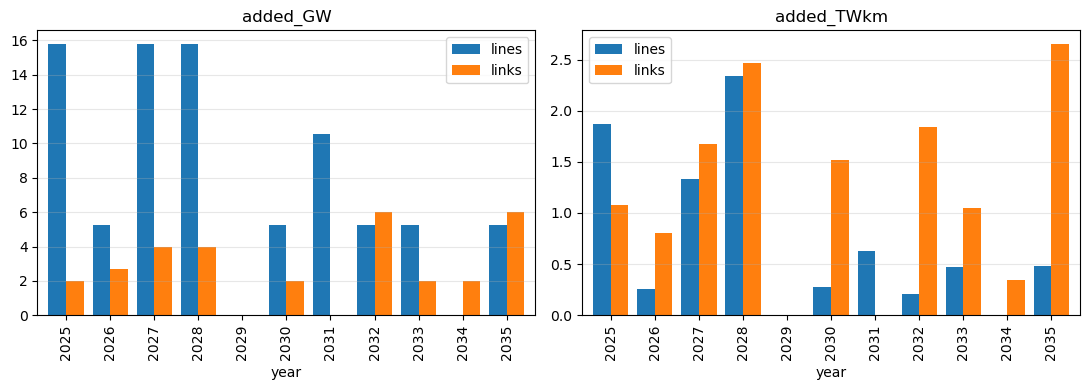

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, unit in zip(axes, ["added_GW", "added_TWkm"]):
    pd.DataFrame({"lines": lines_summary[unit], "links": links_summary[unit]}).plot.bar(ax=ax, width=0.8)
    ax.set_title(unit)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Maps: new-this-year projects over the existing grid

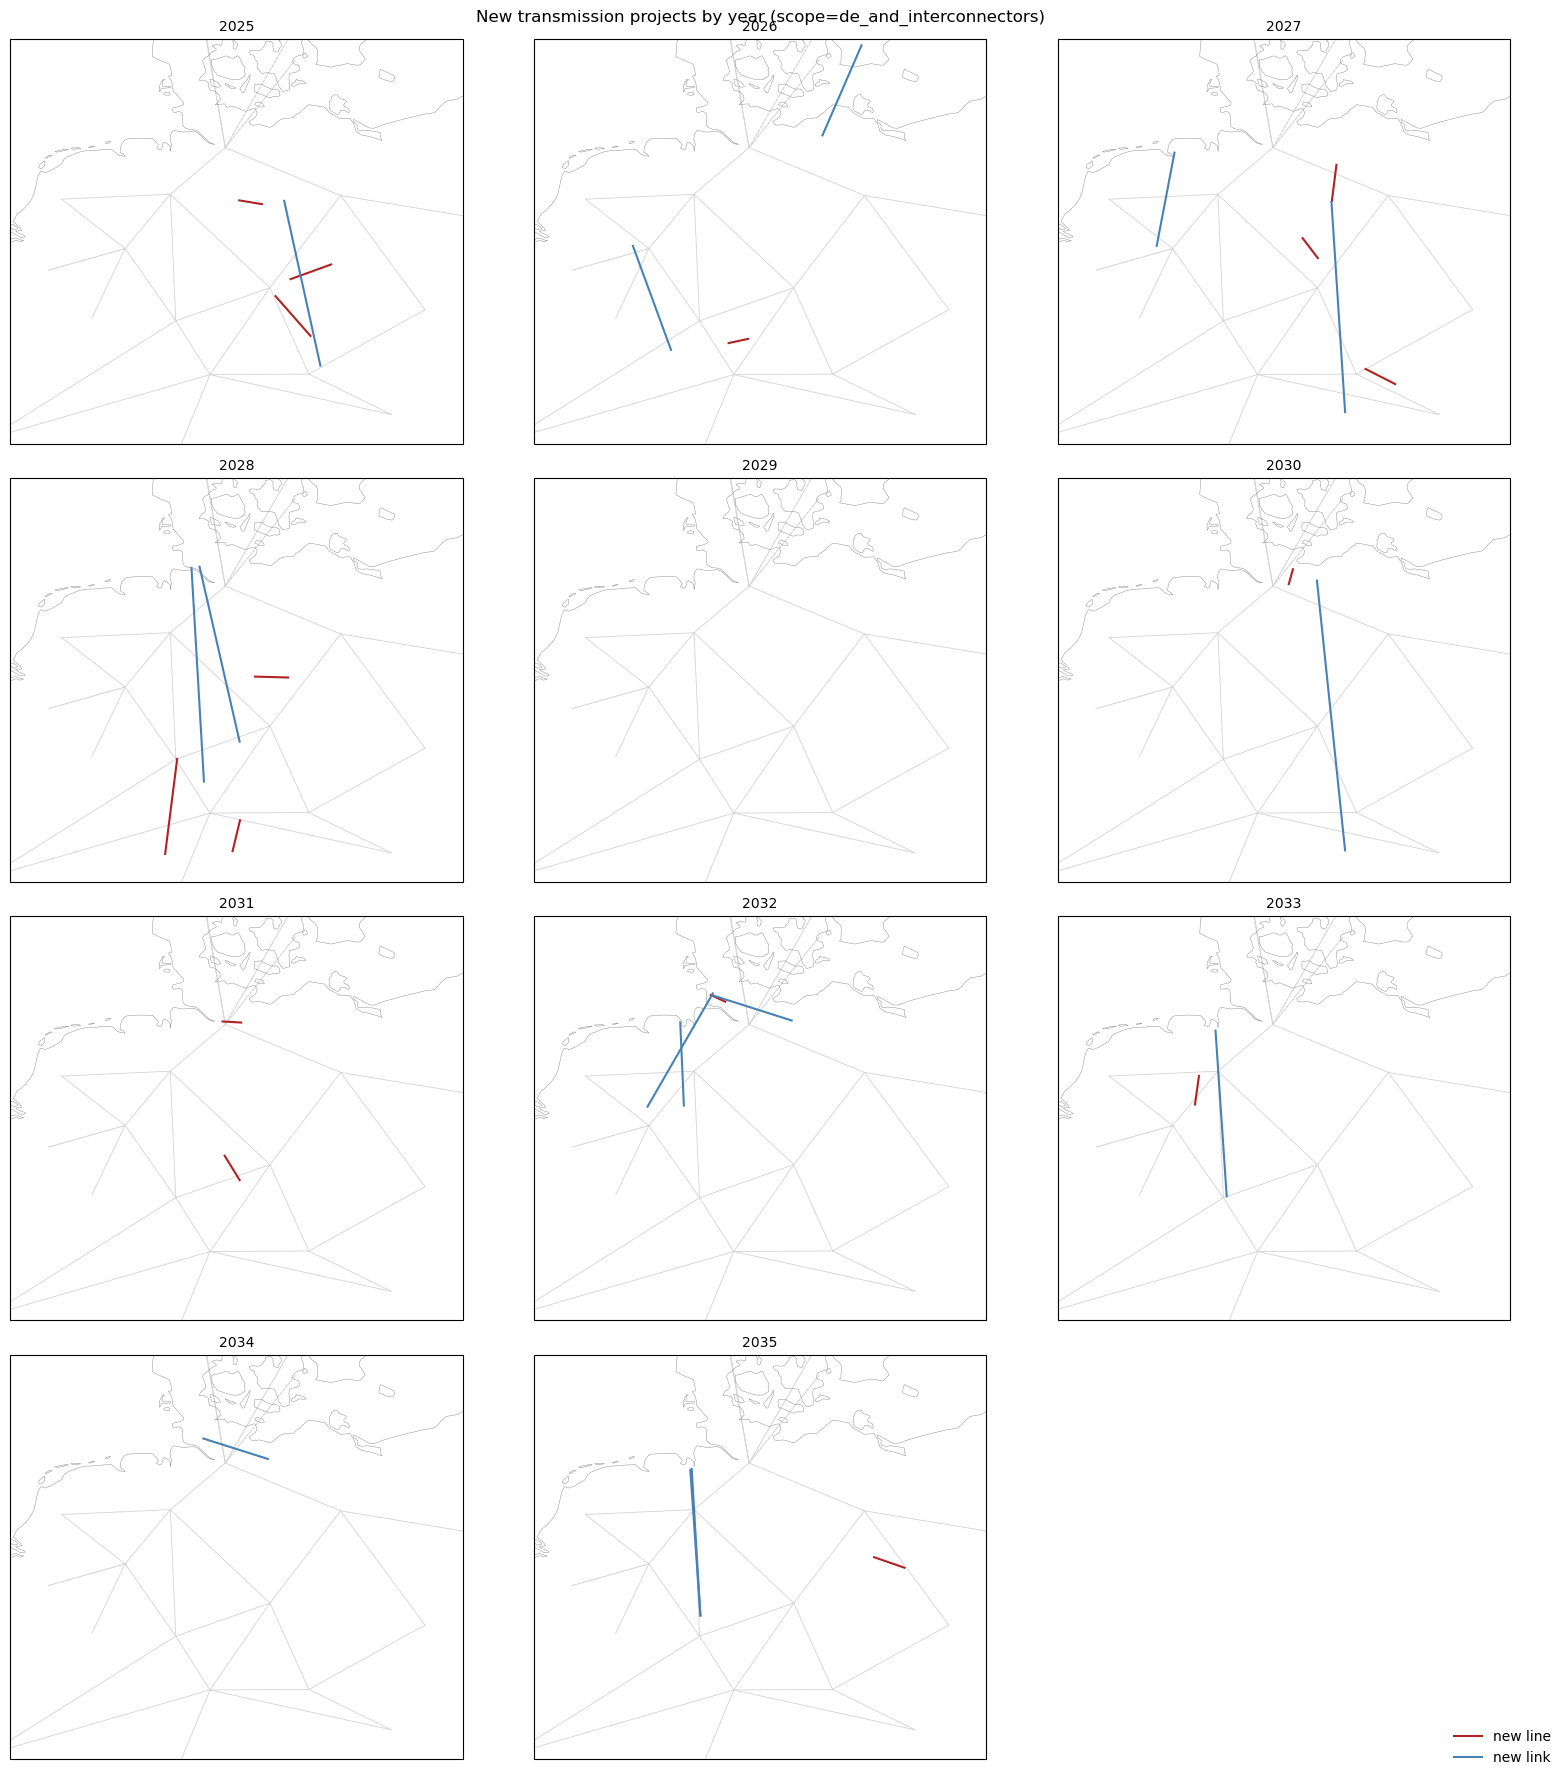

In [6]:
def plot_year(ax, y):
    ax.coastlines(resolution="50m", linewidth=0.3, color="gray")
    ax.set_extent(EXTENT[SCOPE], crs=ccrs.PlateCarree())
    for _, row in existing_lines.iterrows():
        x = [base.buses.at[row.bus0, "x"], base.buses.at[row.bus1, "x"]]
        yy = [base.buses.at[row.bus0, "y"], base.buses.at[row.bus1, "y"]]
        ax.plot(x, yy, transform=ccrs.PlateCarree(), color="lightgray", lw=0.6, zorder=1)
    for _, row in existing_links.iterrows():
        x = [base.buses.at[row.bus0, "x"], base.buses.at[row.bus1, "x"]]
        yy = [base.buses.at[row.bus0, "y"], base.buses.at[row.bus1, "y"]]
        ax.plot(x, yy, transform=ccrs.PlateCarree(), color="lightgray", lw=0.6, ls="--", zorder=1)
    for df, color in [(lines, "firebrick"), (links, "steelblue")]:
        for _, row in df[df.build_year == y].iterrows():
            xx, yy = row.geom.xy
            ax.plot(xx, yy, transform=ccrs.PlateCarree(), color=color, lw=1.5, zorder=2)
    ax.set_title(str(y), fontsize=10)


fig, axes = plt.subplots(4, 3, figsize=(16, 18), subplot_kw={"projection": ccrs.EqualEarth()})
for ax, y in zip(axes.flat, YEARS):
    plot_year(ax, y)
axes.flat[-1].axis("off")
fig.suptitle(f"New transmission projects by year (scope={SCOPE})")
handles = [plt.Line2D([0], [0], color=c, lw=1.5, label=l) for c, l in [("firebrick", "new line"), ("steelblue", "new link")]]
fig.legend(handles=handles, loc="lower right", frameon=False)
plt.tight_layout()
plt.show()